<a href="https://colab.research.google.com/github/trgscott/LELA60331-coursework/blob/main/An_NLP_system_for_the_classification_of_product_review_helpfulness_ratings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **An NLP System for the classification of product review helpfulness ratings**

# **1. Loading the data and libraries**

In [ ]:
# Load the reviews data. Code provided with the assignment.
# Splits fields by tab, creates lists of reviews, product types, sentiment and helpfulness ratings.
!wget https://raw.githubusercontent.com/cbannard/lela60331_24-25/refs/heads/main/coursework/Compiled_Reviews.txt

d = []
reviews=[]
sentiment_ratings=[]
product_types=[]
helpfulness_ratings=[]

with open("Compiled_Reviews.txt") as f:
   for line in f.readlines()[1:]:
        fields = line.rstrip().split('\t')
        reviews.append(fields[0])
        sentiment_ratings.append(fields[1])
        product_types.append(fields[2])
        helpfulness_ratings.append(fields[3])

# Import standard libraries, numpy, matplotlib and tqdm for monitoring progress
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

--2025-01-12 17:02:51--  https://raw.githubusercontent.com/cbannard/lela60331_24-25/refs/heads/main/coursework/Compiled_Reviews.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22322605 (21M) [text/plain]
Saving to: ‘Compiled_Reviews.txt.5’

Compiled_Reviews.tx 100%[===================>]  21.29M  --.-KB/s    in 0.1s    

2025-01-12 17:02:51 (154 MB/s) - ‘Compiled_Reviews.txt.5’ saved [22322605/22322605]



# **2. Top down tokenisation**

In [ ]:
# Lower case
reviews=[txt.lower() for txt in reviews]

# Replace white space characters with a single space
# https://stackoverflow.com/questions/3984539/python-use-regular-expression-to-remove-the-white-space-from-all-lines
reviews=[re.sub(r"^\s+",' ', txt, flags = re.MULTILINE) for txt in reviews]

# Replace major punctuation with a single space (but keeping apostrophes and hyphens to keep them as full words later)
# Adapted from Jurafsky & Martin, Chapter 2
reviews=[re.sub(r"[,.;:?!()\"\]\[]+\ *", ' ', txt) for txt in reviews]

# Replace grammatical words with a single space - same code runs over several times as some are missed due to spacing
# List adapted from https://gist.github.com/sebleier/554280 and by inspecting the most common words / highest weighted words in initial model runs
review1=[re.sub(' no | up | on | i\'ll | quot | there\'s | us | she\'s | he\'s | it\'s | i\'ve | i\'m | im | would | upon | also | i | me | my | myself | we | our | ours | ourselves | you | your | yours | yourself | yourselves | he | him | his | himself | she | her | hers | herself | it | its | itself | they | the | them | their | theirs | themselves | what | which | who | whom | this | that | these | those | am | is | are | was | were | be | been | being | have | has | had | having | do | does | did | doing | a | an | the | and | but | if | or | as | until | while | of | at | by | for | with | about | between | into | through | during | before | after | above | below | to | from | in | out | then | once | here | there | when | where | why | how | all | any | both | each | other | some | such | only | own | same | so | than | too | can | will | just | should | now ',' ', txt) for txt in reviews]
review2=[re.sub(' no | up | on | i\'ll | quot | there\'s | us | she\'s | he\'s | it\'s | i\'ve | i\'m | im | would | upon | also | i | me | my | myself | we | our | ours | ourselves | you | your | yours | yourself | yourselves | he | him | his | himself | she | her | hers | herself | it | its | itself | they | the | them | their | theirs | themselves | what | which | who | whom | this | that | these | those | am | is | are | was | were | be | been | being | have | has | had | having | do | does | did | doing | a | an | the | and | but | if | or | as | until | while | of | at | by | for | with | about | between | into | through | during | before | after | above | below | to | from | in | out | then | once | here | there | when | where | why | how | all | any | both | each | other | some | such | only | own | same | so | than | too | can | will | just | should | now ',' ', txt) for txt in review1]
review3=[re.sub(' no | up | on | i\'ll | quot | there\'s | us | she\'s | he\'s | it\'s | i\'ve | i\'m | im | would | upon | also | i | me | my | myself | we | our | ours | ourselves | you | your | yours | yourself | yourselves | he | him | his | himself | she | her | hers | herself | it | its | itself | they | the | them | their | theirs | themselves | what | which | who | whom | this | that | these | those | am | is | are | was | were | be | been | being | have | has | had | having | do | does | did | doing | a | an | the | and | but | if | or | as | until | while | of | at | by | for | with | about | between | into | through | during | before | after | above | below | to | from | in | out | then | once | here | there | when | where | why | how | all | any | both | each | other | some | such | only | own | same | so | than | too | can | will | just | should | now ',' ', txt) for txt in review2]
reviews=[re.sub(' no | up | on | i\'ll | quot | there\'s | us | she\'s | he\'s | it\'s | i\'ve | i\'m | im | would | upon | also | i | me | my | myself | we | our | ours | ourselves | you | your | yours | yourself | yourselves | he | him | his | himself | she | her | hers | herself | it | its | itself | they | the | them | their | theirs | themselves | what | which | who | whom | this | that | these | those | am | is | are | was | were | be | been | being | have | has | had | having | do | does | did | doing | a | an | the | and | but | if | or | as | until | while | of | at | by | for | with | about | between | into | through | during | before | after | above | below | to | from | in | out | then | once | here | there | when | where | why | how | all | any | both | each | other | some | such | only | own | same | so | than | too | can | will | just | should | now ',' ', txt) for txt in review3]

In [ ]:
# Only capture words (non-numeric) with optional apostrophe or hyphen, words have to be at least 2 letters in length
# Adapted from Jurafsy & Martin Chapter 2
tokenized_sents = [re.findall("[a-z]{2,}(?:-[a-z]+)*(?:'[a-z]+)*",txt) for txt in reviews]

# Collapse all tokens into a single list
tokens=[]
for s in tokenized_sents:
      tokens.extend(s)
# Count the tokens in the tokens list. Returns a list of tuples of each token and count
counts=Counter(tokens)
# Sort the tuples. The reverse argument instructs to put most frequent first rather than last (which is the default)
so=sorted(counts.items(), key=lambda item: item[1], reverse=True)
# Extract the list of tokens, by transposing the list of lists so that there is a list of tokens a list of counts and then just selecting the former
so=list(zip(*so))[0]
# Select all words with 50 or over occurences (after playing around with between 1500-7500 type_list length)
type_list=so[0:4804]

In [ ]:
# Finding 50 or more occurences
check=sorted(counts.items(), key=lambda item: item[1], reverse=True)
print(check[4802:4804])
print(type_list[4803])
len(type_list)

# **3. Creating one-hot encodings**

In [ ]:
# Adapted from seminar 7 code, creates a 36548 x 4804 matrix of zeroes, then fills it with one-hot encodings for each word in each review

M = np.zeros((len(reviews), len(type_list)))
# Iterate over the reviews
for i, rev in enumerate(reviews):
    # Tokenise the current review with the same findall code as noted in the above tokenisation section:
    tokens = re.findall("[a-z]{2,}(?:-[a-z]+)*(?:'[a-z]+)*",rev)
    # Iterate over the words in our type list (the set of 4804 words):
    for j,t in enumerate(type_list):
        # If the current word j occurs in the current review i then set the matrix element at i,j to be one. Otherwise leave as zero.
        if t in tokens:
              M[i,j] = 1

# **4. Split the data into training/development/test sets**

In [ ]:
# Create training (80%), development (10%) and test (10%) sets of the data
train_ints=np.random.choice(len(reviews),int(len(reviews)*0.8),replace=False)
Cut=list(set(range(0,len(reviews))) - set(train_ints))
test_ints=np.random.choice(len(Cut),int(len(Cut)*0.5),replace=False)
dev_ints=list(set(range(0,len(Cut))) - set(test_ints))

# Generate one-hot encoded input matrices for training, development and test
M_train = np.array(M[train_ints,]).T
M_test = np.array(M[test_ints,]).T
M_dev = np.array(M[dev_ints,]).T

unique_labels=list(set(helpfulness_ratings))
unique_one_hot=np.diag(np.ones(len(unique_labels)))

# Create gold labels
helpful_train = [helpfulness_ratings[i] for i in train_ints]
helpful_dev = [helpfulness_ratings[i] for i in dev_ints]
helpful_test = [helpfulness_ratings[i] for i in test_ints]

# Generate one-hot encoded target output matrices for training, development and test
y_train=np.array([list(unique_one_hot[k]) for k in [unique_labels.index(x) for x in helpful_train]]).T
y_test=np.array([list(unique_one_hot[k]) for k in [unique_labels.index(x) for x in helpful_test]]).T
y_dev=np.array([list(unique_one_hot[k]) for k in [unique_labels.index(x) for x in helpful_dev]]).T

#For checking purposes
#review_train = [reviews[i] for i in train_ints]
#review_train[0]

In [ ]:
# Transpose the data
M_train=M_train.T
M_test=M_test.T
M_dev=M_dev.T
y_train=y_train.T
y_test=y_test.T
y_dev=y_dev.T

# **5. Softmax regression using one-hot encodings and L2 regularization**

100%|██████████| 1200/1200 [06:53<00:00,  2.90it/s]


Text(0, 0.5, 'loss')

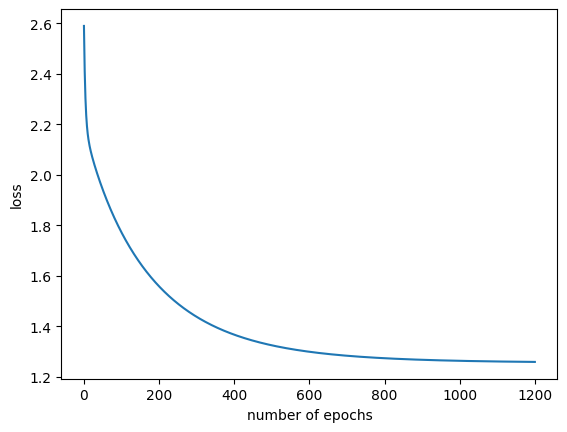

In [ ]:
# Set random seed, set hyperparameters and initialise weights, bias, loss, z and q
np.random.seed(10)
n_iters = 1200
num_features=4804
num_classes=3
num_samples = len(y_train)
weights = np.random.rand(num_features,num_classes)
bias = np.zeros(num_classes) # following lab 9 session that uses num_classes here
lr=0.2
logistic_loss=[]
z=np.zeros((num_samples,num_classes))
q=np.zeros((num_samples,num_classes))

# Training
for i in tqdm(range(n_iters)):

    # Forward pass
    z= M_train.dot(weights) + bias
    z_sum=np.exp(z).sum(axis=1)
    q=np.array([list(np.exp(z_i)/z_sum[i]) for i, z_i in enumerate(z)])

    # Loss calculation
    loss=np.mean(-np.log2((np.sum((y_train*q),axis=1))))

    logistic_loss.append(loss)

    # Backwards pass
    # Add L2 regularization with a lambda value of 0.01 to prevent over-fitting
    dw = 1/num_samples * M_train.T.dot((q-y_train)) + (0.01 * weights)

    # Update weights and bias
    weights=(weights - (dw*lr))
    bias = bias - lr * sum((q-y_train))/num_samples

plt.plot(range(1,n_iters),logistic_loss[1:])
plt.xlabel("number of epochs")
plt.ylabel("loss")

# **6. Softmax interpretation - one-hot encodings and L2**

In [ ]:
#Checking proportions
print(helpful_train.count('neutral'))
print(helpful_train.count('helpful'))
print(helpful_train.count('unhelpful'))

8234
16311
4693


Below is adapted from from lab session 8 to softmax outputs. Words with high weights are those whose presence makes the relevant class most likely. Each weight corresponds to the word at the same position (index) in the type_list. Argsort sorts from low to high so below takes the top 20 to find the indices of the twenty words most strongly associated with e.g. least helpful rating. It's also reversed to find the indices of the 20 words most strongly associated with e.g most helpful.

In [ ]:
# Most neutral.  Positive, delivery/service
print([type_list[x] for x in np.argsort(weights[:,0])[::-1][0:20]])

# Least neutral. Certain product types, negative
print([type_list[x] for x in np.argsort(weights[:,0])[0:20]])

['comfortable', 'loves', 'months', 'phone', 'great', 'nice', 'sent', 'happy', 'extra', 'works', 'love', 'strong', 'the', 'well', 'fast', 'arrived', 'perfect', 'feature', 'size', 'product']
['magazine', 'cd', 'book', 'camera', 'quot', 'dvd', 'movie', 'not', 'review', 'people', 'waste', 'children', 'video', 'film', "wasn't", 'information', 'record', 'mistake', 'rate', 'com']


In [ ]:
# Most helpful. Positive, product quality, recommendation, ease
print([type_list[x] for x in np.argsort(weights[:,1])[::-1][0:20]])

# Least helpful. Certain product types, overly negative, analysis
print([type_list[x] for x in np.argsort(weights[:,1])[0:20]])

['recommend', 'highly', 'quality', 'especially', 'quot', 'easy', 'toy', 'well', 'excellent', 'great', 'program', 'hold', 'use', 'recently', 'very', 'learning', 'works', 'wonderful', 'easier', 'perfect']
['ordering', 'boring', 'album', 'movie', 'character', 'stupid', 'bad', 'anything', 'personally', 'care', 'worst', 'course', 'recieved', 'sent', 'plain', 'playing', 'worse', 'story', 'delivered', 'god']


In [ ]:
# Most unhelpful. Negative, certain product types, analysis, overly negative
print([type_list[x] for x in np.argsort(weights[:,2])[::-1][0:20]])

# Least unhelpful. Positive, product quality, recommendation, ease
print([type_list[x] for x in np.argsort(weights[:,2])[0:20]])

['movie', 'album', 'boring', 'book', 'music', 'game', 'horrible', 'cd', 'character', 'nothing', 'song', 'stupid', 'ordered', 'magazine', 'film', 'person', 'worst', 'mr', 'bad', 'camera']
['great', 'love', 'easy', 'very', 'little', 'nice', 'light', 'fit', 'well', 'perfect', 'wear', 'keep', 'quality', 'using', 'best', 'recommend', 'highly', 'perfectly', 'small', 'purchased']


In [ ]:
# Calculate the predictions using the trained weights on the development set
z = M_dev.dot(weights) + bias
z_sum=np.exp(z).sum(axis=1)
q=np.array([list(np.exp(z_i)/z_sum[i]) for i, z_i in enumerate(z)])
y_dev_pred=np.argmax(q,axis=1)
y_dev_true=np.argmax(y_dev,axis=1)

# Use the above to calculate the confusion matrix entries required to calculated precision and recall
TP=[]
for j in range(3):
 TP.append(np.sum(np.array([int(s == j and y_dev_true[i] == j) for i,s in enumerate(y_dev_pred)])))

FP=[]
for j in range(3):
 FP.append(np.sum(np.array([int(s == j and y_dev_true[i] != j) for i,s in enumerate(y_dev_pred)])))

FN=[]
for j in range(3):
 FN.append(np.sum(np.array([int(s != j and y_dev_true[i] == j) for i,s in enumerate(y_dev_pred)])))

# Calculate the macro-average precision and recall values
PRECISION=np.array(TP)/(np.array(TP)+np.array(FP))
RECALL=np.array(TP)/(np.array(TP)+np.array(FN))

PRECISION_MACROAVERAGE=np.mean(PRECISION)
print(PRECISION_MACROAVERAGE)

RECALL_MACROAVERAGE=np.mean(RECALL)
print(RECALL_MACROAVERAGE)

0.6199216204821586
0.3493415129979094


# **9. Softmax regression - TEST set evaluation**

In [ ]:
# Calculate the predictions using the trained weights on the TEST set
z = M_test.dot(weights) + bias
z_sum=np.exp(z).sum(axis=1)
q=np.array([list(np.exp(z_i)/z_sum[i]) for i, z_i in enumerate(z)])
y_test_pred=np.argmax(q,axis=1)
y_test_true=np.argmax(y_test,axis=1)

# Use the above to calculate the confusion matrix entries required to calculated precision and recall
TP=[]
for j in range(3):
 TP.append(np.sum(np.array([int(s == j and y_test_true[i] == j) for i,s in enumerate(y_test_pred)])))

FP=[]
for j in range(3):
 FP.append(np.sum(np.array([int(s == j and y_test_true[i] != j) for i,s in enumerate(y_test_pred)])))

FN=[]
for j in range(3):
 FN.append(np.sum(np.array([int(s != j and y_test_true[i] == j) for i,s in enumerate(y_test_pred)])))

# Calculate the macro-average precision and recall values
PRECISION=np.array(TP)/(np.array(TP)+np.array(FP))
RECALL=np.array(TP)/(np.array(TP)+np.array(FN))

PRECISION_MACROAVERAGE=np.mean(PRECISION)
print(PRECISION_MACROAVERAGE)

RECALL_MACROAVERAGE=np.mean(RECALL)
print(RECALL_MACROAVERAGE)

0.49890678606733735
0.3479001580294856


In [ ]:
# How many predictions are actually being made vs. the true labels?
print(np.count_nonzero(y_test_pred))
print(np.count_nonzero(y_test_true))

3568
2606


In [ ]:
# Check to see where the model is predicting most/least
print(TP)
print(FP)
print(FN)

[49, 2254, 3]
[38, 1304, 7]
[1000, 28, 321]


**Save final test results for reporting:**

0.49890678606733735

0.3479001580294856


3568

2606


[49, 2254, 3]

[38, 1304, 7]

[1000, 28, 321]

# **10. Neural network model using one-hot encodings**

 *2 layer network, ReLU hidden layer with 3 nod2s and a softmax output layer.*

 Code is adapted from Lab Sessions 10 and 12, and using Practical Linear Algebra for Data Science.

100%|██████████| 300/300 [34:40<00:00,  6.93s/it]


Text(0, 0.5, 'loss')

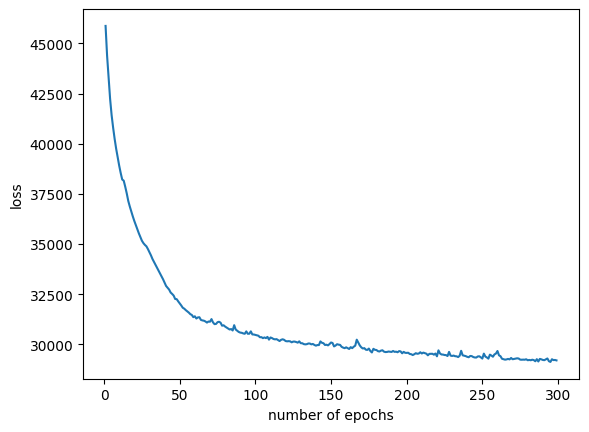

In [ ]:
# Set random seed, set hyperparameters and initialise weights and loss
np.random.seed(10)
lr=0.01 # needed lowering a lot
n_iters = 300 # Limited due to compute time combined with spikiness of loss on higher learning rates
num_features = 4804
hidden_size = 2 # Code would only run with a 2 nodes max (at times it would run with 3 - I could not work out how to debug this unfortunately despite it working on a dummy model)
num_samples = len(y_train)
num_classes = 3
weights_0_1 = np.random.rand(num_features,hidden_size)
weights_1_2 = np.random.rand(hidden_size,num_classes)
loss = []

# Training
for iteration in tqdm(range(n_iters)):
   layer_2_error = 0
   for i in range(len(M_train)):
      layer_0 = M_train[i] # New input layer each loop

      # Forward pass
      layer_1_z = np.dot(layer_0,weights_0_1) # Hidden layer input
      layer_1 = np.maximum(layer_1_z,0) # Hidden layer output (ReLU)

      layer_2_z = np.dot(layer_1,weights_1_2) # Layer 2 input
      layer_2 = np.exp(layer_2_z)/np.exp(layer_2_z).sum() # Output layer (softmax)

      # Calculate the loss for the softmax output layer - taken from softmax training, adjusted for a single pass (no axis needed)
      layer_2_error+=np.mean(-np.log2((np.sum((y_train[i]*layer_2)))))

      # Backward pass
      layer_2_diff = (layer_2 - y_train[i]) # Error2 for each training example

      DW_1_2 = np.outer(layer_1, layer_2_diff) # Derivative for Weights_1_2 - outer product used since its vectors when using an M_train[i] instance loop

      layer_1_delta = np.outer(layer_0,layer_2_diff.dot(weights_1_2.T) * (layer_1>0)) # Derivative for Weights_0_1 - as above for outer product

      # Update the weights
      weights_0_1 -= lr * layer_1_delta
      weights_1_2 -= lr * DW_1_2

   # Append loss calc
   loss.append(layer_2_error)
plt.plot(range(1,n_iters),loss[1:])
plt.xlabel("number of epochs")
plt.ylabel("loss")

# **11. Neural network - interpretation**

In [ ]:
# Matching the highest input layer weights (weights_0_1) with corresponding words in the type_list

# Most neutral
print([type_list[x] for x in np.argsort(weights_0_1[:,0])[::-1][0:20]])

# Least neutral
print([type_list[x] for x in np.argsort(weights_0_1[:,0])[0:20]])

['writes', 'attempts', 'entertained', 'male', 'catchy', 'advice', 'lets', 'hdmi', 'crappy', 'reads', 'sea', 'military', 'pathetic', 'tests', 'scary', "everyone's", 'afraid', 'edit', 'sat', 'moral']
['not', 'get', 'one', 'well', 'great', 'absolute', 'ya', 'favorite', 'subject', 'good', 'over', 'example', 'read', 'organic', 'like', 'hard', 'bottom', 'calories', 'approach', 'most']


In [ ]:
# Most helpful
print([type_list[x] for x in np.argsort(weights_0_1[:,1])[::-1][0:20]])

# Least helpful
print([type_list[x] for x in np.argsort(weights_0_1[:,1])[0:20]])

['believable', 'gears', 'pinnacle', 'exists', 'nero', 'trainer', 'bulb', 'uninstall', 'viewfinder', 'newest', 'gta', 'legal', 'object', 'entering', 'corel', 'serial', 'inspiration', 'join', 'operation', 'geared']
['gamer', 'alternate', 'dealing', 'mats', 'carseat', 'sole', 'leads', 'firewall', 'obscure', 'boat', 'repeated', 'walked', 'complaining', 'newer', 'nyc', 'fool', 'fooled', 'cry', 'surround', 'somebody']


# **12. Neural Network - TEST SET**

In [ ]:
# Calculate the predictions using the trained weights on the TEST set
layer_1_z_test = np.dot(M_test,weights_0_1) # Assuming M_test already transposed in earlier softmax code (otherwise add .T)
layer_1_test = np.maximum(layer_1_z_test,0)
layer_2_z_test = np.dot(layer_1_test,weights_1_2)
z_sum_test = np.exp(layer_2_z_test).sum(axis=1)
layer_2_test = np.array([list(np.exp(layer_2_z_test_i)/z_sum_test[i]) for i, layer_2_z_test_i in enumerate(layer_2_z_test)])

y_test_pred=np.argmax(layer_2_test,axis=1)
y_test_true=np.argmax(y_test,axis=1) # Assuming y_test already transposed in earlier softmax code (otherwise add .T)

In [ ]:
## Calculate the relevant confusion matrix entries
TP=[]
for j in range(3):
 TP.append(np.sum(np.array([int(s == j and y_test_true[i] == j) for i,s in enumerate(y_test_pred)])))

FP=[]
for j in range(3):
 FP.append(np.sum(np.array([int(s == j and y_test_true[i] != j) for i,s in enumerate(y_test_pred)])))

FN=[]
for j in range(3):
 FN.append(np.sum(np.array([int(s != j and y_test_true[i] == j) for i,s in enumerate(y_test_pred)])))

# Calculate macro average precision and recall values
PRECISION=np.array(TP)/(np.array(TP)+np.array(FP))
RECALL=np.array(TP)/(np.array(TP)+np.array(FN))

PRECISION_MACROAVERAGE=np.mean(PRECISION)
print(PRECISION_MACROAVERAGE)

RECALL_MACROAVERAGE=np.mean(RECALL)
print(RECALL_MACROAVERAGE)

0.598573296145421
0.44524250665348086


In [ ]:
# How many predictions are actually being made vs. the true labels?
print(np.count_nonzero(y_test_pred))
print(np.count_nonzero(y_test_true))

2543
2654


In [ ]:
# Check to see where the model is predicting most/least
print(TP)
print(FP)
print(FN)

[377, 1821, 56]
[735, 644, 22]
[624, 529, 248]


**Save for reporting:**

0.598573296145421

0.44524250665348086


2543

2654


[377, 1821, 56]

[735, 644, 22]

[624, 529, 248]

# **13. Word2Vec embeddings**

**Must have already run '1. Loading the data and libraries' and '2. Top down tokenisation' before the below code.**

In [ ]:
# Download w2v embeddings
import gensim.downloader as api
w = api.load('word2vec-google-news-300')
vocab=[x for x in w.key_to_index.keys()]

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
# Match type_list of 4804 words to vocab in embeddings
types=set(type_list)

indices=[vocab.index(x) for x in types if x in vocab]
types_inc=[x for x in types if x in vocab]
G=w[indices]
G.shape

(4766, 300)

In [ ]:
# Create embeddings for each review
embeddings=[]
# Iterate over the reviews
for i, rev in enumerate(reviews):
    # Tokenise the current review with same tokenisation as previous models:
    tokens = re.findall("[a-z]{2,}(?:-[a-z]+)*(?:'[a-z]+)*",rev)
    this_vec = np.zeros((1, 300))
    for t in tokens:
        if t in types_inc:
            this_vec = this_vec + G[types_inc.index(t)]
    embeddings.append(this_vec)
embeddings=np.array(embeddings).squeeze()

In [ ]:
# Scale down embeddings so that the dot products are not so large that they produce errors when calculating z/z_sum/q/loss
# I also tried significantly lowering the learning rate to reduce the weights but this did not work.
embeddings = embeddings / 2

In [ ]:
# Create training (80%), development (10%) and test (10%) sets of the data
train_ints_emb=np.random.choice(len(embeddings),int(len(embeddings)*0.8),replace=False)
Cut_emb=list(set(range(0,len(embeddings))) - set(train_ints_emb))
test_ints_emb=np.random.choice(len(Cut_emb),int(len(Cut_emb)*0.5),replace=False)
dev_ints_emb=list(set(range(0,len(Cut_emb))) - set(test_ints_emb))

# Generate embeddings input matrices for training, development and test
M_train_emb = np.array(embeddings[train_ints_emb,]).T
M_test_emb = np.array(embeddings[test_ints_emb,]).T
M_dev_emb = np.array(embeddings[dev_ints_emb,]).T

# Gold labels
helpful_train_emb = [helpfulness_ratings[i] for i in train_ints_emb]
helpful_dev_emb = [helpfulness_ratings[i] for i in dev_ints_emb]
helpful_test_emb = [helpfulness_ratings[i] for i in test_ints_emb]

# Generate one-hot encoded target output matrices for training, development and test
unique_labels_emb=list(set(helpfulness_ratings))
unique_one_hot_emb=np.diag(np.ones(len(unique_labels_emb)))

y_train_emb=np.array([list(unique_one_hot_emb[k]) for k in [unique_labels_emb.index(x) for x in helpful_train_emb]]).T
y_test_emb=np.array([list(unique_one_hot_emb[k]) for k in [unique_labels_emb.index(x) for x in helpful_test_emb]]).T
y_dev_emb=np.array([list(unique_one_hot_emb[k]) for k in [unique_labels_emb.index(x) for x in helpful_dev_emb]]).T

# **14. Softmax regression using Word2Vec embeddings, L2**



In [ ]:
# Transpose the data
M_train_emb=M_train_emb.T
M_test_emb=M_test_emb.T
M_dev_emb=M_dev_emb.T
y_train_emb=y_train_emb.T
y_test_emb=y_test_emb.T
y_dev_emb=y_dev_emb.T

  0%|          | 0/4000 [00:00<?, ?it/s]<ipython-input-14-a1c8420b14e9>:19: RuntimeWarning: divide by zero encountered in log2
  loss=np.mean(-np.log2((np.sum((y_train_emb*q),axis=1))))
100%|██████████| 4000/4000 [18:25<00:00,  3.62it/s]


Text(0, 0.5, 'loss')

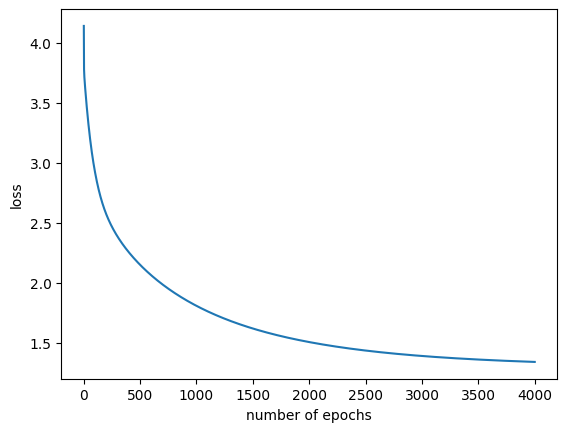

In [ ]:
# Set random seed, set hyperparameters and initialise weights, bias, loss, z and q
np.random.seed(10)
n_iters = 4000
num_features = 300
num_classes = 3
num_samples = len(y_train_emb)
weights = np.random.rand(num_features,num_classes)
bias = np.zeros(num_classes)
lr = 0.01 # anything much more than this very spiky
logistic_loss = []
z = np.zeros((num_samples,num_classes))
q = np.zeros((num_samples,num_classes))

# Training
for i in tqdm(range(n_iters)):

    # Forward pass
    z = (M_train_emb.dot(weights) + bias)
    z_sum = np.exp(z).sum(axis=1)
    q = np.array([list(np.exp(z_i)/z_sum[i]) for i, z_i in enumerate(z)])

    # Loss calculation
    loss=np.mean(-np.log2((np.sum((y_train_emb*q),axis=1))))

    logistic_loss.append(loss)

    # Backward pass
    # Add L2 regularization with a lambda value of 0.01 to the derivative
    dw = 1/num_samples * M_train_emb.T.dot((q-y_train_emb)) + (0.01 * weights)

    # Update weights and bias
    weights -= dw * lr
    bias -= lr * sum((q-y_train_emb))/num_samples

plt.plot(range(1,n_iters),logistic_loss[1:])
plt.xlabel("number of epochs")
plt.ylabel("loss")

# **15. Softmax with Word2Vec and L2 - TEST set evaluation**

In [ ]:
# Calculate the predictions using the trained weights on the TEST set
z = M_test_emb.dot(weights) + bias
z_sum=np.exp(z).sum(axis=1)
q=np.array([list(np.exp(z_i)/z_sum[i]) for i, z_i in enumerate(z)])
y_emb_pred=np.argmax(q,axis=1)
y_emb_true=np.argmax(y_test_emb,axis=1)

# Calculate the relevant values in the confusion matrix
TP=[]
for j in range(3):
 TP.append(np.sum(np.array([int(s == j and y_emb_true[i] == j) for i,s in enumerate(y_emb_pred)])))

FP=[]
for j in range(3):
 FP.append(np.sum(np.array([int(s == j and y_emb_true[i] != j) for i,s in enumerate(y_emb_pred)])))

FN=[]
for j in range(3):
 FN.append(np.sum(np.array([int(s != j and y_emb_true[i] == j) for i,s in enumerate(y_emb_pred)])))

# Calculate macro average precision and recall
PRECISION=np.array(TP)/(np.array(TP)+np.array(FP))
RECALL=np.array(TP)/(np.array(TP)+np.array(FN))

PRECISION_MACROAVERAGE=np.mean(PRECISION)
print(PRECISION_MACROAVERAGE)

RECALL_MACROAVERAGE=np.mean(RECALL)
print(RECALL_MACROAVERAGE)

0.40147148255612636
0.35516988697826474


In [ ]:
# How many predictions are actually being made vs. the true labels?
print(np.count_nonzero(y_emb_pred))
print(np.count_nonzero(y_emb_true))

3550
3333


In [ ]:
# Check to see where the model is predicting most/least
print(TP)
print(FP)
print(FN)

[19, 86, 2122]
[86, 137, 1205]
[303, 949, 176]


**Save for reporting:**

0.40147148255612636

0.35516988697826474


3550

3333


[19, 86, 2122]

[86, 137, 1205]

[303, 949, 176]


---


## **APPENDIX**



---

Error finding code

In [ ]:
#Checking for 'nan' when the neural network didn't run properly
print(layer_0)
print(layer_1_z)
print(layer_1)
print(layer_2_z)
print(layer_2)
print(layer_2_error)
print(y_train[i])
print(layer_2_diff)
print(DW_1_2)
print(layer_1_delta)
print(weights_0_1)
print(weights_1_2)

In [ ]:
#Trying to find an error when the neural network didn't run properly
weights_0_1 = np.random.rand(num_features,hidden_size)
weights_1_2 = np.random.rand(hidden_size,num_classes)
i=1 # change this randomly / loop through to find error

M_train[i].dot(weights_0_1)
np.maximum(M_train[i].dot(weights_0_1),0)
np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2)
np.exp(np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2))/np.exp(np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2)).sum()
np.exp(np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2))/np.exp(np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2)).sum() - y_train[i]
weights_0_1 = weights_0_1 - 0.2 * np.outer(M_train[i],(np.exp(np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2))/np.exp(np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2)).sum() - y_train[i]).dot(weights_1_2.T) * (np.maximum(M_train[i].dot(weights_0_1),0)>0))
weights_1_2 = weights_1_2 - 0.2 * np.outer(np.maximum(M_train[i].dot(weights_0_1),0), np.exp(np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2))/np.exp(np.dot(np.maximum(M_train[i].dot(weights_0_1),0),weights_1_2)).sum() - y_train[i])

print(weights_0_1)
print(weights_1_2)

In [ ]:
# Finding an error before scaling down the embeddings - index will shift around from q[1896] a bit but the error is always the same
np.mean(-np.log2((np.sum((q[0:1896]*y_train_emb[0:1896]),axis=1)))) # fine
np.mean(-np.log2((np.sum((q[0:1897]*y_train_emb[0:1897]),axis=1)))) # breaks
np.mean(-np.log2(np.sum(q[1897]*y_train_emb[1897]))) # fine
q[1896,1] # = 0
(M_train_emb[1896].dot(weights) + bias) # huge positive or negative values e.g. 1467
np.exp(1467) # breaks